In [1]:
import math
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.nn.functional as F
import os
import time
from tqdm.auto import tqdm

import sys
sys.path.insert(0, "/home/palakons/shapevae")#files are relative to singularity home, coz the server is running singularity from there
from model.ptv3_based_model import PointVAE, VAEConfig


from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Subset
from pytorch3d.loss import chamfer_distance
import numpy as np

import wandb




# autoreload py
%load_ext autoreload
%autoreload 2

/home/palakons/.conda/envs/pro_pt3d/lib/python3.10/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


/home/palakons/.conda/envs/pro_pt3d/compiler_compat/ld: cannot find -laio: No such file or directory
collect2: error: ld returned 1 exit status
/home/palakons/.conda/envs/pro_pt3d/compiler_compat/ld: cannot find -laio: No such file or directory
collect2: error: ld returned 1 exit status


In [2]:

from experiment_runner import ExperimentConfig, run_training
from shapenet_dataset import ShapeNetDataset
from visualize import visualize_reconstructions, plot_pointclouds

from model.ptv3_based_model import PointVAE, VAEConfig,check_voxel_collisions
from model.losses import repulsion_exp_loss,loss_fn_cd_plus_real_repulsion,loss_fn_cd,loss_fn_cd_plus_repulsion
from model.base_model import PointCloudAE
from model.base_model import PointCloudAE

# Data Loading & Visualization

In [9]:
%cd ..


/home/palakons


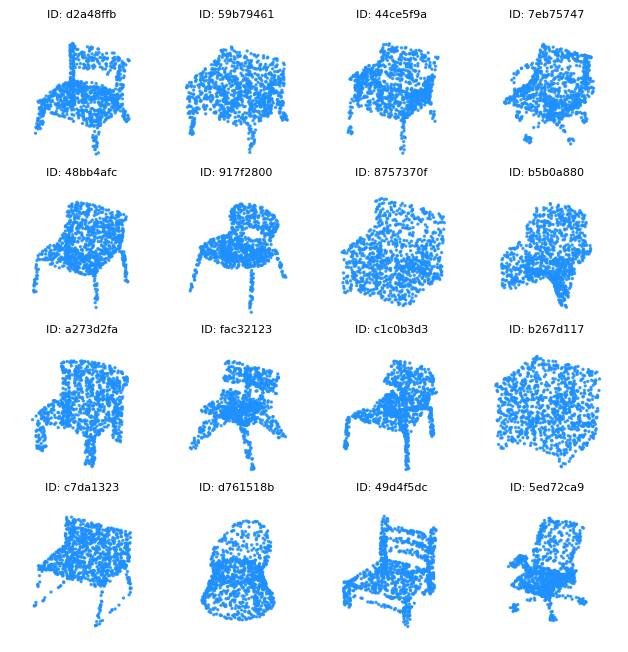

In [10]:
# raw mesh loader was very slow, precompute pointcloud as .npy instead
# precompute with ```python precompute_pointcloud.py --data-dir /ist/ist-share/scads/ploy/scene2/big_file/shapenet/shapenet/ --object-class 03001627 --output-dir ./sampled_poincloud/ --num-points 1024```

dataset = ShapeNetDataset(data_dir='./shapevae/sampled_poincloud/', object_class='03001627')
dataloader = DataLoader(dataset, batch_size=16, shuffle=True)

# plot 3d scatter of first batch
for batch in dataloader:
    pcs = batch['points']  # shape (B, N, 3)
    ids = batch['object_id']
    pc_list = list(zip(ids, pcs))
    plot_pointclouds(pc_list)
    break

## Experiment Flow

- Define model and loss directly in this notebook for each experiment.
- Use `run_training(...)` from `experiment_runner.py` for training loop, checkpoints, metrics, tqdm, and optional wandb.

## Experiment List
- Baseline 1: Base model (no seed), Loss: Chamfer.
- Baseline 2: Base model (no seed), Loss: Chamfer + Repulsion.

## Setting up

In [11]:
# Shared configs for all runs
z_dim = 1024
batch_size = 16
num_epochs = 100
lr = 1e-3
val_split = 0.1
seed = 42
run_root="/shapevae_weights"

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

# Notebook-safe default: multiprocessing DataLoader workers can trigger
# "can only test a child process" cleanup errors in Jupyter.
num_workers = 0

torch.manual_seed(seed)
np.random.seed(seed)

num_points = dataset[0]["points"].shape[0]
all_indices = np.arange(len(dataset))
train_idx, val_idx = train_test_split(
    all_indices, test_size=val_split, random_state=seed, shuffle=True
)
train_set = Subset(dataset, train_idx)
val_set = Subset(dataset, val_idx)

train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=num_workers,
    pin_memory=(device == "cuda"),
)
val_loader = DataLoader(
    val_set,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=(device == "cuda"),
)

device: cuda


## Baseline 1

In [6]:
# 1) Baseline experiment: Chamfer Distance only
model_cd = PointCloudAE(z_dim=z_dim, num_points=num_points)
optimizer_cd = torch.optim.Adam(model_cd.parameters(), lr=lr)
loss_fn_cd = lambda recon, points: chamfer_distance(
    recon.float(),
    points.float(),
    batch_reduction="mean",
    point_reduction="mean",
)[0]

cfg_cd = ExperimentConfig(
    name="baseline_cd",
    num_epochs=num_epochs,
    seed=seed,
    use_amp=True,
    save_every=10,
    run_root=run_root,)

run_dir_cd, summary_cd = run_training(
    config=cfg_cd,
    model=model_cd,
    optimizer=optimizer_cd,
    loss_fn=loss_fn_cd,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
)
print("Baseline CD run dir:", run_dir_cd)
print("Baseline CD summary:", summary_cd)

wandb: Currently logged in as: palakon-k to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


[baseline_cd] interpolation anchors selected: idx=[60, 439, 310, 592], ids=['7a427785ad85f0c771c3cf047830ec1f', '48f0c9b02587b5a8ea0588dd0d874b1e', 'bb4f5cd713a817727d4f8900c5174db0', '920af478601258e24762da3a3017ade']


train:baseline_cd:   0%|          | 0/425 [00:00<?, ?it/s]

[baseline_cd] epoch 1/1 train 0.015196 val 0.011505 best 0.011505


epoch,▁
train/loss,▁
val/best,▁
val/loss,▁
best_epoch,1
best_val,0.0115
epoch,1
run_dir,/shapevae_weights/20...
train/loss,0.0152
val/best,0.0115
val/loss,0.0115


Baseline CD run dir: /shapevae_weights/20260427-101945_palakons_baseline_cd
Baseline CD summary: {'best_val': 0.01150479943080004, 'best_epoch': 1}


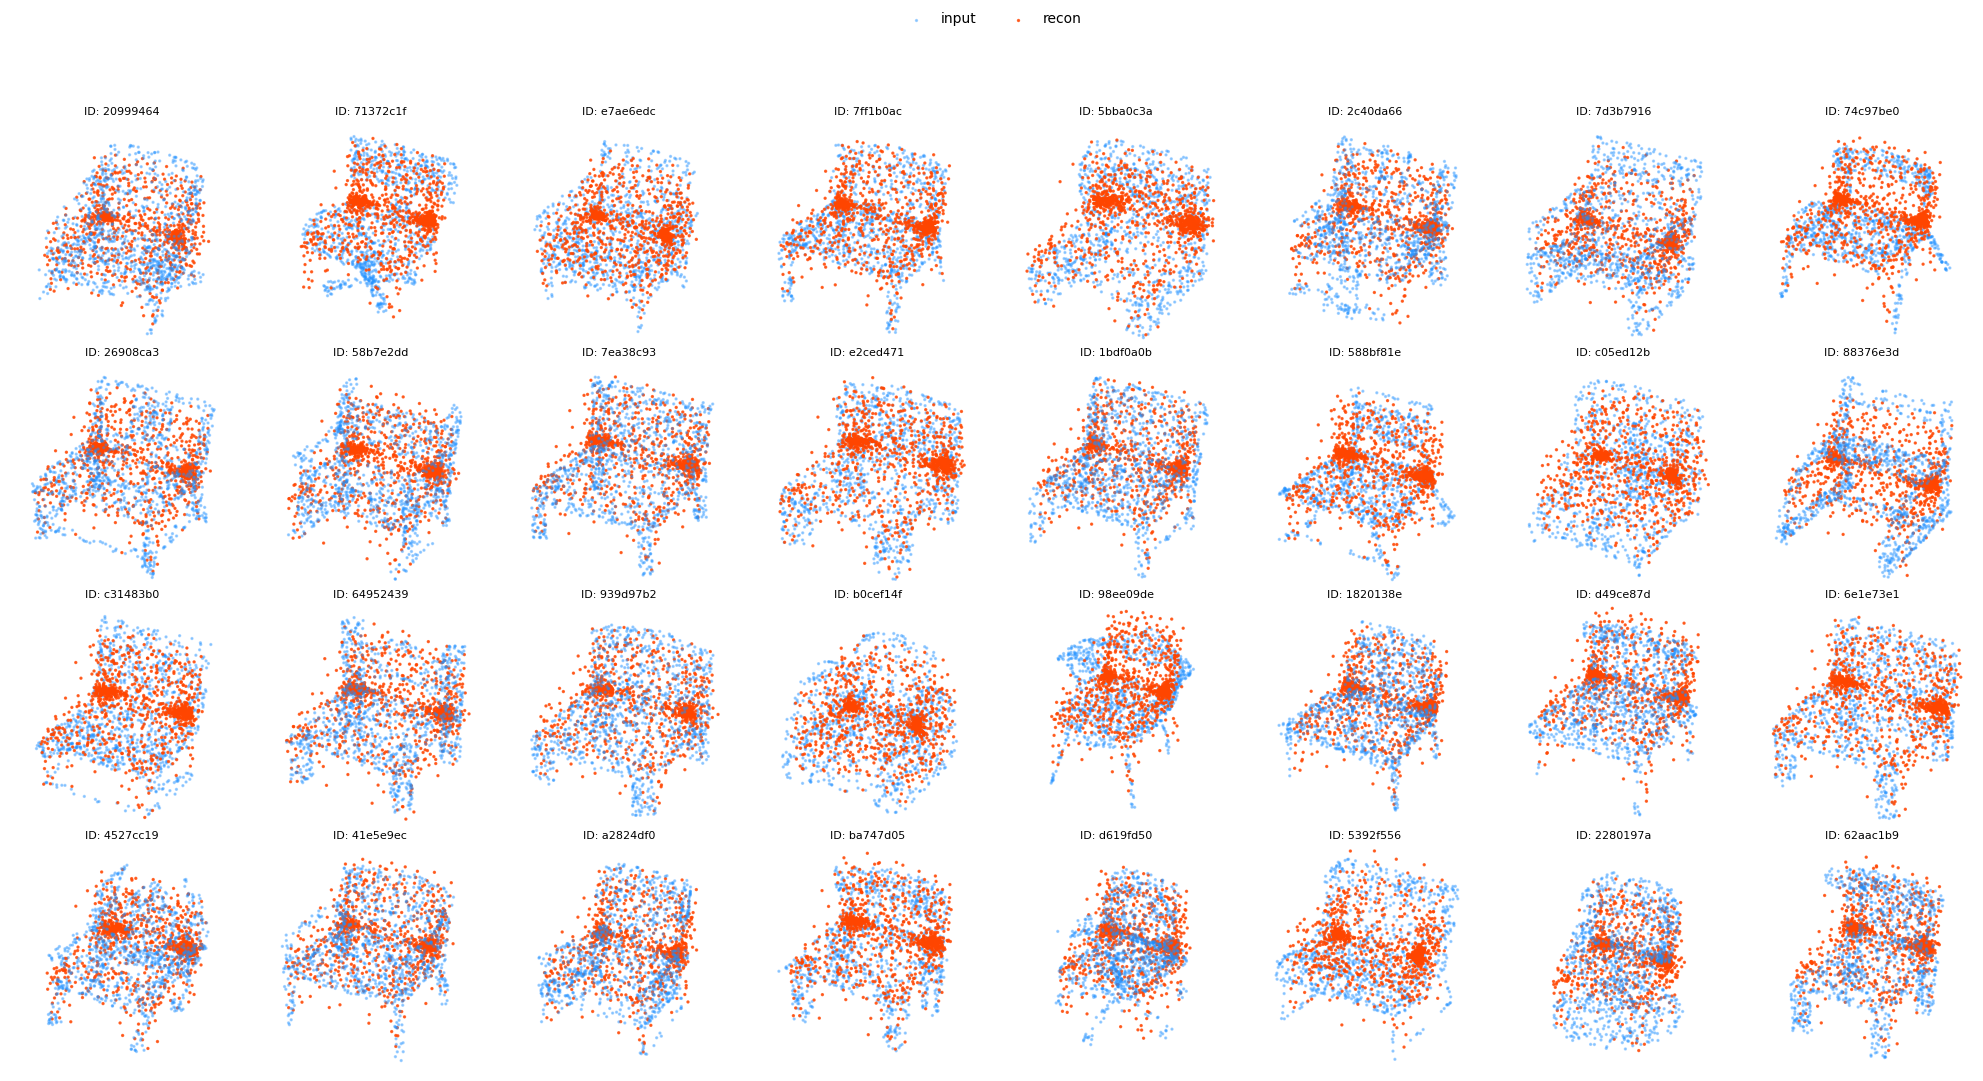

In [7]:
# Visualize baseline reconstructions across N validation batches
visualize_reconstructions(
    model=model_cd,
    loader=val_loader,
    device=device,
    num_batches=2,
    n_cols=8,
)

In [11]:
# 2) Baseline skeleton: Chamfer + Repulsion
# Keep model/optimizer definitions explicit; only loss changes.
model_rep = PointCloudAE(z_dim=z_dim, num_points=num_points)
optimizer_rep = torch.optim.Adam(model_rep.parameters(), lr=lr)



cfg_cd_rep = ExperimentConfig(
    name="baseline_cd_plus_repulsion_skeleton",
    num_epochs=num_epochs,
    seed=seed,
    use_amp=False,
    save_every=10,
    run_root=run_root,
)

print("Repulsion skeleton ready: implement repulsion_loss_placeholder, then uncomment run.")
run_dir_rep, summary_rep = run_training(
    config=cfg_cd_rep,
    model=model_rep,
    optimizer=optimizer_rep,
    loss_fn=loss_fn_cd_plus_repulsion,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
)

Repulsion skeleton ready: implement repulsion_loss_placeholder, then uncomment run.


[baseline_cd_plus_repulsion_skeleton] interpolation anchors selected: idx=[60, 439, 310, 592], ids=['7a427785ad85f0c771c3cf047830ec1f', '48f0c9b02587b5a8ea0588dd0d874b1e', 'bb4f5cd713a817727d4f8900c5174db0', '920af478601258e24762da3a3017ade']


train:baseline_cd_plus_repulsion_skeleton:   0%|          | 0/425 [00:00<?, ?it/s]

[baseline_cd_plus_repulsion_skeleton] epoch 1/1 train 0.015711 val 0.011834 best 0.011834


epoch,▁
train/loss,▁
val/best,▁
val/loss,▁
best_epoch,1
best_val,0.01183
epoch,1
run_dir,/shapevae_weights/20...
train/loss,0.01571
val/best,0.01183
val/loss,0.01183


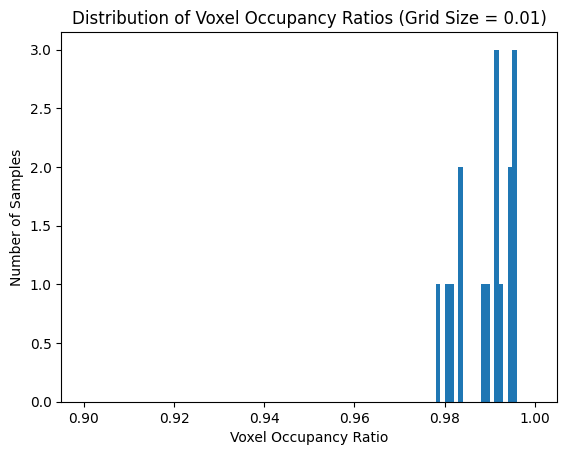

In [12]:

#fetch one batch of training data, and check for collisions , for grid sizes .01 for all smaples in the batch

batch = next(iter(train_loader))
occ_ratios = []
for i in range(batch["points"].shape[0]):
    pts = batch["points"][i]
    collision_info = check_voxel_collisions(pts, grid_size=0.01)
    occ_ratios.append(collision_info["occupancy_ratio"])
    
plt.hist(occ_ratios, bins=100, range=(0.9, 1.0))
plt.xlabel("Voxel Occupancy Ratio")
plt.ylabel("Number of Samples")
plt.title("Distribution of Voxel Occupancy Ratios (Grid Size = 0.01)")
plt.show()

assert min(occ_ratios) > 0.9, "Some samples have very low occupancy ratio, consider increasing grid size or implementing a more robust repulsion loss."


In [ ]:
# 3) PTv3-based skeleton: Chamfer + Repulsion 
# Keep model/optimizer definitions explicit; only loss changes.

cfg = VAEConfig(hidden_dim=64, latent_dim=128, num_points=1024, variational=False, grid_size=.01)
model_ptv3 = PointVAE(cfg=cfg)
optimizer_ptv3 = torch.optim.Adam(model_ptv3.parameters(), lr=lr)


cfg_cd_rep = ExperimentConfig(
    name="ptv3_cd_plus_repulsion",
    num_epochs=num_epochs,
    seed=seed,
    use_amp=False,
    save_every=10,
    run_root=run_root,
)

print("Repulsion skeleton ready: implement repulsion_loss_placeholder, then uncomment run.")
run_dir_ptv3, summary_ptv3 = run_training(
    config=cfg_cd_rep,
    model=model_ptv3,
    optimizer=optimizer_ptv3,
    loss_fn=loss_fn_cd_plus_real_repulsion,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
)

Repulsion skeleton ready: implement repulsion_loss_placeholder, then uncomment run.


wandb: Currently logged in as: palakon-k to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


[ptv3_cd_plus_repulsion] interpolation anchors selected: idx=[60, 439, 310, 592], ids=['7a427785ad85f0c771c3cf047830ec1f', '48f0c9b02587b5a8ea0588dd0d874b1e', 'bb4f5cd713a817727d4f8900c5174db0', '920af478601258e24762da3a3017ade']


train:ptv3_cd_plus_repulsion:   0%|          | 0/42500 [00:00<?, ?it/s]

W0427 11:18:04.087000 78 site-packages/torch/fx/_symbolic_trace.py:52] is_fx_tracing will return true for both fx.symbolic_trace and torch.export. Please use is_fx_tracing_symbolic_tracing() for specifically fx.symbolic_trace or torch.compiler.is_compiling() for specifically torch.export/compile.


# Without Repulsion

In [ ]:

cfg = VAEConfig(hidden_dim=64, latent_dim=128, num_points=1024, variational=False, grid_size=.01)
model_ptv3_norepulsion = PointVAE(cfg=cfg)
optimizer_ptv3_norepulsion = torch.optim.Adam(model_ptv3_norepulsion.parameters(), lr=lr)


cfg_cd_norepulsion = ExperimentConfig(
    name="ptv3_cd_norepulsion",
    num_epochs=num_epochs,
    seed=seed,
    use_amp=False,
    save_every=10,
    run_root=run_root,# changed from "runs" to the shared directory on NAS
)

print("Repulsion skeleton ready: implement repulsion_loss_placeholder, then uncomment run.")
run_dir_ptv3_norepulsion, summary_ptv3_norepulsion = run_training(
    config=cfg_cd_norepulsion,
    model=model_ptv3_norepulsion,
    optimizer=optimizer_ptv3_norepulsion,
    loss_fn=loss_fn_cd,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
)

# VAE CD + Repulsion

In [ ]:
cfg = VAEConfig(hidden_dim=64, latent_dim=128, num_points=1024, variational=True, grid_size=.01)
model_ptv3_vae_repulsion = PointVAE(cfg=cfg)
optimizer_ptv3_vae_repulsion = torch.optim.Adam(model_ptv3_vae_repulsion.parameters(), lr=lr)



cfg_cd_vae_repulsion = ExperimentConfig(
    name="ptv3_cd_vae_repulsion",
    num_epochs=num_epochs,
    seed=seed,
    use_amp=False,
    save_every=10,
    run_root=run_root,# changed from "runs" to the shared directory on NAS
)

print("Repulsion skeleton ready: implement repulsion_loss_placeholder, then uncomment run.")
run_dir_ptv3_vae_repulsion, summary_ptv3_vae_repulsion = run_training(
    config=cfg_cd_vae_repulsion,
    model=model_ptv3_vae_repulsion,
    optimizer=optimizer_ptv3_vae_repulsion,
    loss_fn=loss_fn_cd_plus_real_repulsion,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
)

# VAE with Chamfer Loss only

In [ ]:
cfg = VAEConfig(hidden_dim=64, latent_dim=128, num_points=1024, variational=True, grid_size=.01)
model_ptv3_vae_norepulsion = PointVAE(cfg=cfg)
optimizer_ptv3_vae_norepulsion = torch.optim.Adam(model_ptv3_vae_norepulsion.parameters(), lr=lr)



cfg_cd_vae_norepulsion = ExperimentConfig(
    name="ptv3_cd_vae_norepulsion",
    num_epochs=num_epochs,
    seed=seed,
    use_amp=False,
    save_every=10,
    run_root=run_root,# changed from "runs" to the shared directory on NAS
)

print("No repulsion skeleton ready: implement no_repulsion_loss_placeholder, then uncomment run.")
run_dir_ptv3_vae_norepulsion, summary_ptv3_vae_norepulsion = run_training(
    config=cfg_cd_vae_norepulsion,
    model=model_ptv3_vae_norepulsion,
    optimizer=optimizer_ptv3_vae_norepulsion,
    loss_fn=loss_fn_cd,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
)